## import libraries

In [17]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import DataLoader
from collections import Counter
import emoji
import re
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Loading Model

In [3]:
model_name = "michellejieli/emotion_text_classifier"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

In [4]:
emotion_map = {0: 'anger', 1: 'disgust', 2: 'fear', 3: 'joy', 4: 'neutral', 5: 'sadness', 6: 'surprise'}

## Preprocessing functions

In [8]:
# Preprocessing functions
def remove_emoji(text):
    return emoji.replace_emoji(text, replace="")

def msg_clean(msg):
    # Remove URL
    msg = re.sub(r'https?://\S+|www\.\S+', " ", msg)

    # Remove Mentions
    msg = re.sub(r'@\w+', ' ', msg)

    # Remove Digits
    msg = re.sub(r'\d+', ' ', msg)

    # Remove HTML tags
    msg = re.sub(r'<.*?>', ' ', msg)

    # Remove Emoji from text
    msg = remove_emoji(msg)

    # Remove Stop Words (optional - customize stopword removal if needed)
    stopword = set()  # Define your stopword set if required
    msg = msg.split()
    msg = " ".join([word for word in msg if word not in stopword])

    return msg

In [9]:
def preprocess_transcripts_text(df):
    columnName = "whisper_voice_to_text"
    # Remove unwanted characters
    df[columnName] = df[columnName].str.replace(r"[;:.,!&\-_$?'\"]", '', regex=True)
    # Lowercase and clean text
    df[columnName] = df[columnName].str.lower()
    df[columnName] = df[columnName].apply(msg_clean)
    return df

# Preprocess comments for tokenizer
def preprocess_comments(comments):
    return tokenizer(comments, padding=True, truncation=True, return_tensors="pt")

# Get emotion probabilities
def get_emotion_probabilities(probs):
    emotion_probabilities = []
    for prob in probs:
        emotion_probs = {emotion_map[i]: float(prob[i]) for i in range(len(emotion_map))}
        emotion_probabilities.append(emotion_probs)
    return emotion_probabilities

# Classify emotions in batch
def classify_emotions_batch(comments_batch):
    inputs = preprocess_comments(comments_batch)
    inputs = {key: value.to(device) for key, value in inputs.items()}  # Move inputs to GPU
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    return get_emotion_probabilities(probs)

In [10]:
def word_count(string):
    return len(string.split())

## Load Data

In [11]:
transcripts_data = pd.read_csv("June_July_August_transcripts.csv")

/tmp/ipykernel_1262472/3327127709.py:1: DtypeWarning: Columns (1,2,3,4,6,7,9,13,14,15,16,17,18,22,23,24,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,2

In [12]:
transcripts_data = transcripts_data.iloc[:,:29]

## community (Specific set of users)

In [13]:
d2 = {0: ['thenewparty24',
  'cpdat68',
  'ruddforyourlife',
  'whoissizzle',
  'ray.parsons24',
  'legacyvote',
  'hyunblackn',
  'gracie_joyce',
  'indigoskeye',
  'danyulo_o',
  'gotharza',
  'suttonsmart',
  'sickghoulspodcast',
  'youalreadyknowme_10',
  'worldwidetexas',
  'trump_supporters_24',
  'thelasttalkshow',
  'truth_n_funnies',
  'suggsybenz',
  'youmustevolve1',
  'slydaspydase7entv',
  'venezolanonini',
  'f1nr1r_',
  'realbldentalkz',
  'fyp.sellers',
  'kristiadams705',
  'realhiwhy',
  'matthew_keith_martin',
  'sanctus90',
  'moissanitewatch14',
  'pretty_girl_trish1',
  'magafirst2024',
  'poonamn16',
  'shadowimages7',
  'thegaypsychotherapist',
  'sarahbristle',
  'kwaku3636',
  'mediaking11',
  'opeylove',
  'lukekincadecomedy11',
  'po.litico',
  'mimiandpopshomestead',
  'sacheycertified',
  'bakerscustomapparel',
  'beardzandbiblez',
  'wayoutfunhouse',
  'brothersteph83',
  'swaglobsta24',
  'chefmikec718',
  'missbuyer_',
  'brooksthepatriot2003',
  'creationsbykm1',
  'dutydriven',
  'dustycalifornia',
  'cpetcare2',
  'clintbristow',
  'cris.cringle4',
  'thee_anicole',
  'emilyo7onthe',
  'itsnotmichelllvd',
  'charlitfit',
  'locktour',
  'peterbilt389official',
  'stayconsciouss',
  'clip0day',
  'zekeduchati',
  'aitunetech',
  'skibididoodad',
  'queenilove00',
  '18xpsyopvictim',
  'abelfashion',
  'bringtrumpback202',
  'michael_walker_us_senate'],
 2: ['brittanybaileymade',
  'toniaann1',
  'hn.since.1989',
  'xn.since1989',
  'sn.since1989',
  'hd.since1989',
  'commandertrumpinator',
  'f1r3w4ll',
  'rivery.trendy',
  'duettrinh',
  'wrldoflyrics_',
  'th.since1994',
  'pattern_play_tees',
  'trendytee62',
  'majumendoncabeneditot',
  'nicolerlondow',
  'kenta.clothing',
  'mrsbrittanybrinson3',
  'triplesssshop',
  'endiadavisss',
  'teecheap',
  'oldmoneystyleco',
  'jaimdelanei',
  'ochossi71',
  'laura.leach.studi',
  'jmuehl77',
  'kylescabin00',
  'uno.1989',
  'mark.garrett',
  'conservativescentral',
  'kaylawouters',
  'lifeisshortdigit',
  'michelleuspatriot',
  'thetrumptee.store',
  'adambyrne208',
  'birdieleighleigh',
  'spt.since.1989',
  'zandra.sendejo7',
  'lovelljames123',
  'jacyglovershop93',
  'josephine.tuilagi',
  'josephshop1978',
  'sallyspickard1985',
  'vicky.woodall',
  'slaphw',
  'josephinetrevino83',
  'terryslsqa9',
  'luxeandloft',
  'premium.tee.palace',
  'tn.since.1999',
  'rapper.101',
  'maya.trendi.tee',
  'sharelldamonllc',
  'willislauryn100',
  'trumpp1io',
  'tizen_boutique89',
  'trendytee206',
  'jokeworld.ai1',
  'martinking877',
  'rctestflight.fan_',
  'dalziel.kelvin',
  'musictshirt.hz',
  'korneroutletfashion',
  'jessica051104',
  'charles.brosh',
  'erikagalvan1981',
  'davidsergent93',
  'emersontowne',
  'benpacheco1962',
  'joebeall11231',
  'belairman21',
  'chanceks9821',
  'brandonelsner97',
  'asoletovilod',
  '1010gelblaster725',
  'graphicgroove2024',
  '.dani._',
  'death_drop101'],
 3: ['patriot_maga2025',
  'trump.fans7',
  'yoshithepatriot76',
  'trumporbust2024',
  'trumpismtribe',
  'wethepeoplearenotblind',
  'trump.unstoppable',
  'trumps_aura',
  'ww4455668',
  'tty76890',
  'zucchini.flower',
  'trumpwasrighteverything',
  'unclefknruckus',
  'remmytv',
  'videojunkie1974',
  'keithwebb00',
  'larrykingthe3rd',
  'lazyeyepolitics',
  'patrick_shepherd',
  'patifyonyoutube',
  'politicalenjoyer1',
  'patriot_avenger',
  'teamtrump_24',
  'stacybeck67',
  'hal_for_ny__',
  'lareelp',
  'stephaniehalverson22',
  'trendmaker_official',
  'kai423824',
  'littlehouseintheprairie',
  'jeffreybarron71',
  'marcusdeegan',
  'b.roach',
  'bossbaby41580',
  'chawkeewhite',
  'flashreportnews',
  'hellaviralclipz',
  'hazdemi_tumejorobra',
  'jennyraeca',
  'aicelebritycovers',
  'coffey_5',
  'kimpatton1119',
  'genxlibertylover',
  'dailyclips4yall',
  'crissyrose1985',
  'gotrumper2024',
  'jenniferbrady13',
  'magaaf1972',
  'kaitrump86',
  'mrstownsend1',
  'ericbonesteel',
  'maryannburris',
  'flawskyworld',
  'albeantacopico',
  'a543212345a',
  'chaos_faery',
  '_brandilyn',
  'bucslayer'],
 4: ['trumpmerchnet',
  'sometimescoolthings',
  'trumpfanpage52',
  'trumplegacy20',
  'trumppulse12',
  'trumpintel00',
  'trumpdirect89',
  'trumpinsights99',
  'trumpwire89',
  'trumpfeed00',
  'trumpbrief99',
  'usaforever99',
  'trumpdaily789',
  'usavoice987',
  'trumpvanguard755',
  'trumwarrior2024',
  'trumptoday06',
  'usa_valorwave',
  'trumptriumphchampion',
  'trumpspiritchampion',
  'donaltrump2024president',
  'number1_trumpsupporters',
  'hoopmonster0',
  'number1_trumpteam',
  'ourlasthope2024',
  'jamesppci9z',
  'jamesytyll5',
  'maga_heroes',
  'fusion2024i',
  'trump2024____3',
  'macaroniproduction',
  'e.l.o.n.m.u.s.k',
  'ed.kanon',
  'cyptovikingnft',
  'beckamw20',
  'americapathforge'],
 5: ['trantemsyna',
  'waseetlx3i4',
  'xuan1312y3n',
  'vikasvgp03y',
  'wisnuayt00a',
  'vikesqnf4zn',
  'vutanusriky',
  'trantvqdu4v',
  'tuan22484k4',
  'vandurpmff1',
  'tsilphzqt3z',
  'tuanlyuug4p',
  'ujalavhgznl',
  'trinhwtpgvh',
  'tuyenvirjrc',
  'tuhinyqt52f',
  'marifhkfh2m',
  'mosamwtyw56',
  'mdrajprr4si',
  'soupyefndf5',
  'mparmhsll3m',
  'nandumab78x',
  'musartru7lr',
  'maurarzln4a',
  'nguyepips0x',
  'mdkowmhy956',
  'sharmtinzh9',
  'mmanjephooe',
  'mshahyyeinh',
  'mfahioqiz14',
  'na854655m92',
  'nguyexvx2st',
  'mdkhacrab4w',
  'mdbalqrucwd',
  'soyebbdj74d',
  'md8123610zi',
  'md522234rvi',
  'mdsaiexhb9r',
  'marohclafyh',
  'mdsarzgn2fe',
  'mr0103736m8',
  'minhaoshtqs',
  'mdfortyv4vu',
  'mdr87265pjg',
  'mdfoywvolts',
  'mdsahjss3du',
  'mmdeimaiqat',
  'nguyezsysvz',
  'mojamgsbpcx',
  'mokimemgtgo',
  'neluttcz0me',
  'neworoxc0sz',
  'mishayichv1',
  'nandiubxq2o',
  'mehedfzu8om',
  'speedellfvu',
  'mehunkud5z4',
  'ngoanhjndro',
  'tinkucpkay1',
  'nanaduxcmjb',
  'moshauutcz0',
  'mwhanmgzpce',
  'motardkjfaa',
  'mdshasat4u2',
  'mdiqbuidb8m',
  'lokhatbv4mn',
  'marewxkzsds',
  'manimjeeqk7',
  'manuemvr2hz',
  'maitiydk2d6',
  'mahakisdyr8',
  'madarqaqhe0',
  'malebcbhfx5',
  'mahabclmt6a',
  'marbenqsqze',
  'mahesvqocny',
  'maraqkpmsqb',
  'mardaralo44',
  'madanfisoxx',
  'maitifxp1a1',
  'manisbrcar2',
  'mahenhwqtn4',
  'mangabgnxis',
  'mahboeigg0h',
  'mamatugxcxp',
  'marconfxl9k',
  'luongxily9u',
  'm2402318ezo',
  'mariateveu3',
  'maivainh39c',
  'maharsuf1lv',
  'luongjth1s9',
  'mamanmridg5',
  'maivantjbm4',
  'luongxnph5w',
  'lol25647g8b',
  'malikwouhgg',
  'madarbwpfpi',
  'margooks12z',
  'loudjkomjob',
  'mahenprdolc',
  'malekbwzzxo',
  'majeditihxd',
  'manumcejzns',
  'luongoqc4d3',
  'aslammobjh9',
  'lalbatjn71h',
  'azamqacqll5',
  'b96241213h0',
  'keyshpem855',
  'khanaqwuocv',
  'lethioeqr9e',
  'levanbynbg0',
  'banchbuu3wx',
  'lethixpwiml',
  'letrobxortj',
  'babokjqzqfn',
  'linhcfptj08'],
 6: ['vanthygh9tz',
  'truonbsrp74',
  'trantzpf37l',
  'trantjzllou',
  'truonqhjixk',
  'mr016807u49',
  'mukeszpjw3j',
  'tanhaccg5av',
  'narengif5gj',
  'minhpiquudp',
  'nguyesqejxu',
  'tomarjeiegy',
  'morshkql3qb',
  'spasoaiqc87',
  'mojhaxbz0cz',
  'malimmqis61',
  'maivaqpz9j0',
  'maphieofkn8',
  'mdjuyqbcj92',
  'mahesniedx3',
  'manubekzk59',
  'atkulagrqtn',
  'lokesblhxwp',
  'avi81202b8e',
  'latasgbk0nj',
  'loan1405t8t',
  'asrafkzo1gh'],
 7: ['hannygotgames1',
  'hannynanny748',
  'ur.fav.gamer69',
  'iamhanny60',
  'hannyxesx83',
  'michijazz',
  'helloojazz',
  'mishijazz',
  'youronlyjazz',
  'prettybea2023',
  'redbea2024',
  'lovely.bianca.cak',
  'nicola.price4',
  'itsmee.nicola',
  'nicolamiami',
  'eda_just',
  'grrjazz',
  'funnybea2023',
  'eda_a_s',
  'bea2023happy',
  'beabunny2023',
  'bea.kiss8'],
 8: ['user5185338725952',
  'user52020936324603',
  'user7132386932966',
  'user8706837173775',
  'user7941247756724',
  'user9081556530013',
  'user72813513953424',
  'user59866503172818',
  'user9887792057051',
  'user5384059721120',
  'user6226108355879',
  'user94705590034403',
  'user7215395725773',
  'user7779955072374',
  'jenniferacirbal6',
  'katesmith1129',
  'user2560794328285',
  'user44002961833770',
  'user4580856714635',
  'user1662746904747',
  'user2485304603976',
  'user3254732190715',
  'user3785884812335',
  'user12206876549483',
  'user2133606911266',
  'user4021394434977',
  'user18202005584',
  'user1945525944290',
  'user4187621431934',
  'user46909415987740',
  'beckymurray874'],
 9: ['royallovetales4',
  'royalromancer_',
  'verse_light_',
  'whispersofdesire2',
  'shadowedserenade',
  'veiledvirtue3',
  'whisperoflove__',
  'storyseeker3',
  'eerieembrace',
  'obsidianopus_',
  'midnightmysteries5',
  'midnightdesires_2',
  'litwishes1',
  'forbiddendesire_2',
  'forbiddensecretsunravel2',
  'enchantedlovebooks',
  'inkwhirl4',
  'pagechic',
  'eeriertlr',
  'kucutedesire',
  'blissrealm_',
  'amourromantictales4'],
 10: ['gothicgarden4',
  'romanticresonance',
  'raquellreads',
  'romancereadtrail',
  'kidnappedheartfeltlove',
  'whispersofpassion',
  'noveltide',
  'talewish',
  'storyluxe7',
  'sweetstorybooks_5',
  'lit_love_janeth',
  'sinistersecrets__',
  'tranquil_tranquility_',
  'storyfairytales6',
  'echowhisper6',
  'enigmaticallurelooms_',
  'anabellareads_',
  'blissfulstorylover_',
  'bookswith_kiara',
  'blissfulwhims',
  'darkflick_',
  'bookwander6',
  'bookswith_hayden',
  'bookishdreamzone'],
 11: ['nickmlnw2xp',
  'victosxf54t',
  'samanwvq22o',
  'victobodi3f',
  'vershqfttzs',
  'terramza5gu',
  'reenaesvddd',
  'raulszpamai',
  'samhoezir60',
  'rachawvyk37',
  'roberathuue',
  'sanaiiwxha9',
  'jasonqhezwt',
  'michaaajnt7',
  'johnnhrhn79',
  'katiecrxv71',
  'madisejyvbl',
  'latifnfmogi',
  'melesdwoqmv',
  'ericlktcrlg',
  'jagrgdndgpr',
  'jamesvgtd38',
  'camerzpnqcu',
  'emmahuffbpt',
  'carolgff1mn',
  'danelofz1cy',
  'danibffxtts',
  'carsoljtnpv',
  'davidxfirsw',
  'amandpzkw0p',
  'america.news.pulse',
  'bekkijeouc7',
  'camertwf3zj'],
 12: ['madelyn87840',
  'user7943523016316',
  'yoi7370',
  'olivia75553',
  'nolan722364',
  'robert121287',
  'serenity722916',
  'nrgzpuspk1m',
  'usllapxia17',
  'nora722353',
  'user5345786996137',
  'nnpjbdfuogl',
  'mwvruahxtwe',
  'tgedsuwsqy3',
  'soarmugjx6d',
  'yggespjeatb',
  'vvjdaahg7n6',
  'user5315858126251',
  'user3679761776875',
  'autumn75450',
  'believesinkinto14',
  'entice785',
  'landon722971',
  'kinsley1945',
  'gabriella06828',
  'madelyn121193',
  'delilah1869',
  'christian121718',
  'easton75254',
  'landon75973',
  'james75890',
  'ava121684',
  'charlotte87851',
  'charlotte121538',
  'fieowvdxjjn',
  'colton8889',
  'kzzenhnk1wr',
  'ccmktfovxjl',
  'ddyrtrps4rb',
  'jvcgfcwe9pa',
  'hmqqskcbzjn',
  'hunter75611',
  'cooper75101',
  'easton8256',
  'joseph75510',
  'madelyn87516',
  'allison121152',
  'autumn75204'],
 13: ['steps.in.pfp.bio1478',
  'steps.in.pfp.bio181',
  'steps.in.pfp.bio859',
  'steps.in.pfp.bio825',
  'steps.in.pfp.bio229',
  'steps.in.pfp.bio797',
  'steps.in.pfp.bio46',
  'steps.in.pfp.bio499',
  'steps.in.pfp.bio7730',
  'steps.in.pfp.bio658',
  'steps.in.pfp.bio306',
  'steps.in.pfp.bio640',
  'steps.in.pfp.bio4423',
  'steps.in.pfp.bio200',
  'steps.in.pfp.bio8333',
  'steps.in.pfp.bio2528',
  'steps.in.pfp.bio947',
  'steps.in.pfp.bio993',
  'tt220291',
  'gaming.chair.sb2',
  'gaming.chair.ia'],
 1: ['trumpfreedomfighther',
  'trumpsforamerica',
  'trumpruler',
  'trumpnoble0',
  'trumplegacy2',
  'trumpxtreme3',
  'trumprevolution1',
  'trumpnation35',
  'trumployalist4',
  'trumpresolve',
  'trumppeak',
  'trumpgladiator',
  'trumppatriotunite',
  'trumptornado1',
  'trumpnoble',
  'trumpwavewatch',
  'trumptimeslive',
  'trumpsphere4',
  'trumpquantum',
  'trumprevival1',
  'trumpvortex',
  'trumpk67',
  'trumphero_1',
  'trumpwave_2024',
  'trumpvibesonly',
  'trumpsboldvision',
  'trumployallegacy',
  'trumpsvictoryvision',
  'trumpsupporters_united',
  'trumppowerhouse',
  'trunpgaze',
  'trumpsnapz',
  'trumpworldview',
  'thetrumpeffect',
  'trump_prime',
  'trump_phantom',
  'trumpchampion2',
  'trump_tornado',
  'trumpascend',
  'trumpenergy',
  'trump_visionary1',
  'trump_universe1',
  'trump_trendsetter',
  'trump_talks0',
  'trump_spotlight',
  'trump_spark',
  'trump_pulse',
  'trump_legend1',
  'trump_legacy1',
  'trump_hype2',
  'trump_hype1',
  'trump_era1',
  'trum_prevolution',
  'trump4greatness',
  'trumpadvance',
  'trumpecho2024',
  'trumpdynamicforce',
  'trump4thepeople',
  'trump24winning',
  'trumpaurax',
  'trumpempirex',
  'trump_visionary',
  'trumpbrilliance',
  'trumpeagle',
  'trumpexcellence',
  'trumpamericafirst',
  'trumpchampion3',
  'trumpaspire']}

## emotional analysis

In [249]:
june = transcripts_data[transcripts_data['utc_month'] == 8]
june_post_assasin = june[(june['utc_day']>=26) & (june['utc_day']<=31)]
june_post_assasin.dropna(subset=['whisper_voice_to_text'],inplace=True)
june_post_assasin['view_count'] = pd.to_numeric(june_post_assasin['view_count'], errors='coerce')
june_post_assasin['like_count'] = pd.to_numeric(june_post_assasin['like_count'], errors='coerce')
june_post_assasin['share_count'] = pd.to_numeric(june_post_assasin['share_count'], errors='coerce')
june_post_assasin['comment_count'] = pd.to_numeric(june_post_assasin['comment_count'], errors='coerce')

/tmp/ipykernel_2488416/2284318243.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  june_post_assasin.dropna(subset=['whisper_voice_to_text'],inplace=True)
/tmp/ipykernel_2488416/2284318243.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  june_post_assasin['view_count'] = pd.to_numeric(june_post_assasin['view_count'], errors='coerce')
/tmp/ipykernel_2488416/2284318243.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

In [250]:
june_post_assasin['word_count'] = june_post_assasin['whisper_voice_to_text'].apply(word_count)
june_post_assasin = june_post_assasin[june_post_assasin['word_count'] > 20]

/tmp/ipykernel_2488416/3756570154.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  june_post_assasin['word_count'] = june_post_assasin['whisper_voice_to_text'].apply(word_count)


In [26]:
temp_a[['view_count','like_count','share_count','comment_count']].describe()

,view_count,like_count,share_count,comment_count
count,4.970000e+02,497.000000,497.000000,487.000000
mean,4.980515e+04,3696.311871,409.128773,223.761807
std,2.261348e+05,17640.613945,3086.892589,1115.666411
min,0.000000e+00,0.000000,0.000000,0.000000
25%,4.110000e+02,43.000000,1.000000,4.000000
50%,9.140000e+02,94.000000,4.000000,11.000000
75%,3.370000e+03,224.000000,19.000000,46.000000
max,2.225207e+06,216533.000000,44591.000000,18045.000000


In [254]:
meaningful_posts = june_post_assasin[
    (june_post_assasin['view_count'] > 445) | 
    (june_post_assasin['like_count'] > 38) | 
    (june_post_assasin['share_count'] > 1) | 
    (june_post_assasin['comment_count'] > 5)
]

In [11]:
temp = transcripts_data[transcripts_data.username.isin(communities[10])]

In [13]:
temp.dropna(subset=['whisper_voice_to_text'],inplace=True)

/tmp/ipykernel_3580563/2323421803.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp.dropna(subset=['whisper_voice_to_text'],inplace=True)


In [15]:
meaningful_posts = temp

In [16]:
# Batch processing
batch_size = 32  # Adjust batch size based on GPU memory
data_loader = DataLoader(meaningful_posts['whisper_voice_to_text'].tolist(), batch_size=batch_size)
emotion_results = []

for batch in data_loader:
    batch_emotions = classify_emotions_batch(batch)
    emotion_results.extend(batch_emotions)

In [17]:
emotion_df = pd.DataFrame(emotion_results)
meaningful_posts.reset_index(inplace=True)
meaningful_posts = pd.concat([meaningful_posts, emotion_df], axis=1)

In [19]:
meaningful_posts['emotion'] = meaningful_posts[[ 'anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness',
       'surprise']].idxmax(axis=1)

In [21]:
meaningful_posts['emotion'].value_counts()

emotion
neutral     63
joy         35
disgust     11
sadness      6
fear         5
anger        5
surprise     3
Name: count, dtype: int64

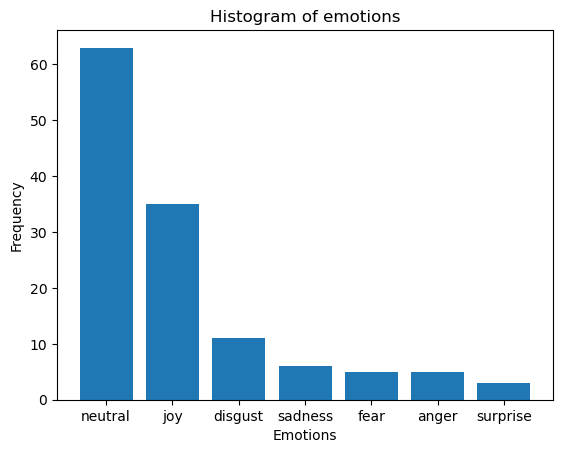

In [22]:
value_counts = meaningful_posts['emotion'].value_counts()

# Plot the histogram
plt.bar(value_counts.index, value_counts.values)
plt.title('Histogram of emotions')
plt.xlabel('Emotions')
plt.ylabel('Frequency')
plt.show()

In [264]:
# Save the results to a new CSV
meaningful_posts.to_csv("emotion_analysis_results_august_week5.csv", index=False)
print("Emotion analysis completed and saved.")

Emotion analysis completed and saved.
